In [1]:
import os
import gc
import yaml
import json
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

import matplotlib.pyplot as plt
from plotnine import *

num_cores = multiprocessing.cpu_count()
print(num_cores)

16


## Code

In [2]:
def process_phenotypes_prs_long(
    gene_trait_df: pl.DataFrame,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    config: dict,
) -> pl.DataFrame:
    """
    Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.
    """
    print("Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.")
    
    # --- Step 1: Unique phenotypes ---
    unique_phenotypes = gene_trait_df['phenotype'].unique().to_list()
    if not unique_phenotypes:
        raise ValueError("No phenotypes found in gene_trait_df")

    # --- Step 2: Read data ---
    phenos = (
        pl.read_parquet(pheno_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + unique_phenotypes)
        .drop_nulls()
    )

    prs_cols = [f"{pheno}_prs" for pheno in unique_phenotypes]
    prs = (
        pl.read_parquet(prs_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + prs_cols)
        .drop_nulls()
    )

    cov_list = config.get("covariates", [])
    cov_df = (
        pl.read_parquet(cov_path)
        .rename({'sample': 'individual'})
        .select(['individual'] + cov_list)
        .with_columns(pl.col('individual').cast(pl.Int64))
    )

    # --- Step 3: Merge all into one DataFrame ---
    all_df = phenos.join(prs, on='individual', how='inner').join(
        cov_df, on='individual', how='inner'
    )
    all_pd = all_df.to_pandas()

    # --- Step 4: Compute residuals ---
    all_residuals_dfs = []

    for phenotype in unique_phenotypes:
        try:
            pheno_cols = [phenotype, f"{phenotype}_prs"] + cov_list
            temp_df = all_pd[['individual'] + pheno_cols].dropna()
            if len(temp_df) == 0:
                print(f"No data for phenotype: {phenotype}")
                continue

            y = temp_df[phenotype]
            X = temp_df.drop(columns=[phenotype, 'individual'])
            X = sm.add_constant(X)

            model = sm.OLS(y, X).fit()
            residuals = pd.Series(model.resid, index=temp_df.index, name=f"{phenotype}_residual")

            pheno_residuals = pd.concat([temp_df[['individual']], residuals], axis=1)
            all_residuals_dfs.append(pheno_residuals)

        except Exception as e:
            print(f"Error processing phenotype {phenotype}: {e}")
            continue

    if not all_residuals_dfs:
        raise ValueError("No residuals could be computed")

    # --- Step 5: Convert to long-format Polars DataFrame ---
    long_dfs = []
    for residual_df in all_residuals_dfs:
        p_wide = pl.DataFrame(residual_df).with_columns(
            pl.col('individual').cast(pl.String)
        )
        pheno_cols = [c for c in p_wide.columns if c.endswith('_residual')]
        pdf = (
            p_wide.unpivot(
                index=['individual'],
                on=pheno_cols,
                variable_name='phenotype',
                value_name='pheno_value',
            )
            .with_columns(
                pl.col('phenotype').str.replace('_residual', '').alias('phenotype')
            )
        )
        long_dfs.append(pdf)

    combined_pdf = pl.concat(long_dfs) if len(long_dfs) > 1 else long_dfs[0]

    return combined_pdf

def process_gene_genotypes(
    gene_id: str, 
    regions_dict: dict, 
    sample_list: list
) -> pl.DataFrame:
    """
    Extract genotypes for a specific gene
    """
    try:
        reg_dict = regions_dict[gene_id]
        geno = reg_dict['genotypes']
        
        # Find heterozygous genotypes (genotype == 1)
        rows, cols = np.where(geno == 1)
        het = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 1
        })
        
        # Find homozygous genotypes (genotype == 2)
        rows, cols = np.where(geno == 2)
        hom = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 2
        })
        
        geno_melt = pl.concat([het, hom]).with_columns(
            pl.lit(gene_id).alias('region')
        )
        
        return geno_melt
        
    except Exception as e:
        print(f"Error processing genotypes for gene {gene_id}: {e}")
        return None

def bootstrap_samples(
    gpa_df: pl.DataFrame, 
    n_bootstraps: int, 
    seed: int = None
) -> pl.DataFrame:
    """
    Bootstrap samples for correlation analysis
    """
    if seed is not None:
        np.random.seed(seed)

    # Get unique individuals
    unique_ids = gpa_df.select('individual').unique().to_series().to_list()
    n_ids = len(unique_ids)

    # Prepare all bootstrap samples
    sampled_ids = np.random.choice(unique_ids, size=(n_bootstraps, n_ids), replace=True)

    # Flatten and make DataFrame with bootstrap_id
    boot_id_col = np.repeat(np.arange(n_bootstraps), n_ids)
    sampled_flat = pl.LazyFrame({
        'bootstrap_id': boot_id_col,
        'individual': sampled_ids.ravel()
    })

    # Lazy join to replicate rows
    boot_df = sampled_flat.join(gpa_df.lazy(), on='individual', how='left')

    # Group by bootstrap_id + original grouping columns
    result = (
        boot_df
        .group_by(['bootstrap_id', 'id', 'phenotype', 'region', 'annotation'])
        .agg([
            pl.len().alias('n_individuals'),
            pl.col('pheno_value').mean().alias('mean_pheno_value'),
            pl.col('score').mean().alias('mean_score'),
        ])
        .collect()
    )

    return result

In [3]:
def corr_pipeline(
    gene_trait_df: pl.DataFrame,
    anngeno_path: str,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    new_annotations_path: str,
    config: dict,
    maf: float = None,
    eur_samples_path: str = None,
    corr_method: str = "pearson",
    save_path: str = None,
    only_missense_vars: bool = False,
    all_vars: bool = False,
):
    """
    Main processing pipeline for gene-trait correlation analysis.
    """

    # Process phenotypes (PRS + covariate correction)
    combined_pdf = process_phenotypes_prs_long(
        gene_trait_df,
        pheno_path,
        prs_path,
        cov_path,
        config,
    )

    # Initialize AnnGeno
    print("Loading AnnGeno...")
    ag = AnnGeno(anngeno_path, mode='r', low_mem=True)

    if maf:
        variants_to_keep = (
            ag.annotations.filter(pl.col('af_ukb') <= maf)
            .select('id')
            .collect()['id']
        )
        ag.subset_variants(set(variants_to_keep))

    eur_samples = None
    if eur_samples_path:
        eur_samples = pl.read_csv(eur_samples_path).with_columns(
            pl.col("eid").cast(pl.Utf8)
        )['eid'].to_list()
        ag.subset_samples(set(eur_samples))

    # Get regions
    unique_genes = gene_trait_df['gene_id'].unique().to_list()
    regions_dict = ag.get_many_regions(unique_genes)

    # Load new scores
    if new_annotations_path:
        print("Adding new scores to benchmark...")
        new_anno = pl.read_parquet(new_annotations_path).filter(pl.col('region').is_in(unique_genes))

    # Collect annotation categories
    all_annotation_list = []
    rare_variant_annotations_dict = config.get("rare_variant_annotations")
    if rare_variant_annotations_dict:
        for category in rare_variant_annotations_dict.values():
            all_annotation_list.extend(category)

    all_results = []
    pheno_gis_df = None  # last computed pheno_gis_df, useful when plotting for a single gene-trait pair

    gene_to_traits = (
        gene_trait_df.group_by("gene_id")
        .agg(pl.col("phenotype").unique().alias("phenotypes"))
    )

    # --- Loop by gene, compute genotypes once ---
    for row in tqdm(gene_to_traits.iter_rows(named=True), total=len(gene_to_traits)):
        gene_id = row["gene_id"]
        phenotypes = row["phenotypes"]

        print(f"Processing gene {gene_id} with {len(phenotypes)} phenotypes")

        geno_melt = process_gene_genotypes(gene_id, regions_dict, ag.samples)
        if geno_melt is None:
            print(f"No genotype data for {gene_id}")
            continue

        anno_df = regions_dict[gene_id]["annotations"]

        # TODO!
        if new_annotations_path:
            new_anno_gene = new_anno.filter(pl.col("region") == gene_id).pivot(
                index=['mutant', 'gene_id', 'gene_name'],
                on='dms_type',
                values='dms_score'
            ).drop_nulls()

        # --- Loop over phenotypes for this gene ---
        for phenotype in phenotypes:
            pheno_data = combined_pdf.filter(pl.col("phenotype") == phenotype)
            if len(pheno_data) == 0:
                print(f"No phenotype data for {phenotype}")
                continue

            gp_df = geno_melt.join(pheno_data, on="individual")

            if eur_samples is not None:
                gp_df = gp_df.filter(pl.col("individual").is_in(eur_samples))

            gp_df = gp_df.filter(pl.col("genotype") == 1)
            if len(gp_df) == 0:
                print(f"No valid genotype-phenotype data for {gene_id} - {phenotype}")
                continue

            if new_annotations_path:
                if 'id' in new_anno_gene.columns:
                    anno_wide = anno_df.join(new_anno_gene, on='id', how='inner')
                elif 'mutant' in new_anno_gene.columns:
                    anno_wide = anno_df.join(new_anno_gene, on='mutant', how='inner')
                else:
                    print(f"No matching column for joining new annotations for {gene_id}")
                    continue
                available_annotations = list(set(all_annotation_list) & set(anno_wide.columns)) + new_anno_gene.columns[3:]
            else:
                anno_wide = anno_df
                available_annotations = list(set(all_annotation_list) & set(anno_wide.columns))

            if not available_annotations:
                print(f"No valid annotations for {gene_id}")
                continue

            if only_missense_vars:
                anno_wide = anno_wide.filter(pl.col('consequence_missense_variant') == 1)

            anno_melt = anno_wide.unpivot(
                index=['id', 'region', 'af_ukb'],
                on=available_annotations,
                variable_name='annotation',
                value_name='score',
            ).with_columns(
                pl.col('score').cast(pl.Float32).alias('score')
            )

            ## Add all variant scores
            if all_vars:
                annos_all_vars = list(set(all_annotation_list) & set(anno_df.columns))
                all_anno_melt = anno_df.filter(pl.col('consequence_missense_variant') == 1).unpivot(
                    index=['id', 'region'],
                    on=annos_all_vars,
                    variable_name='annotation',
                    value_name='score',
                ).with_columns(
                    (pl.col('annotation') + "_allvars").alias('annotation')
                )
                anno_melt = pl.concat([anno_melt, all_anno_melt])

            gpa_df = gp_df.join(anno_melt, on='id', how='inner')
            if len(gpa_df) == 0:
                print(f"No data after joining annotations for {gene_id} - {phenotype}")
                continue

            # --- correlation step ---
            pheno_gis_df = (
                gpa_df.group_by(['id', 'phenotype', 'region', 'annotation'])
                .agg([
                    pl.len().alias('n_individuals'),
                    pl.col('pheno_value').mean().alias('mean_pheno_value'),
                    pl.col('score').mean().alias('score'),
                ])
                .drop_nulls(subset=['mean_pheno_value', 'score'])
            )
            if len(pheno_gis_df) == 0:
                continue

            corr_df = (
                pheno_gis_df.group_by(['annotation', 'phenotype', 'region'])
                .agg(pl.corr('score', 'mean_pheno_value', method=corr_method).alias('corr'))
                .with_columns(pl.col('corr').abs().alias('abs_corr'))
                .filter(pl.col('abs_corr').is_not_null())
                .sort('abs_corr', descending=True)
                .with_columns([
                    pl.lit(gene_id).alias('gene_id'),
                    pl.lit(phenotype).alias('phenotype_name'),
                ])
            )

            all_results.append(corr_df)

    # Combine results
    final_corr_df = pl.concat(all_results)
    print(f"Final correlation results shape: {final_corr_df.shape}")
    if save_path:
        final_corr_df.write_parquet(f'{save_path}/multi_gene_trait_correlations.parquet')

    return pheno_gis_df, final_corr_df

## Polars Lazy

In [ ]:
def process_phenotypes_prs_long(
    gene_trait_df: pl.DataFrame,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    config: dict,
) -> pl.DataFrame:
    """
    Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.
    """
    print("Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.")
    
    # --- Step 1: Unique phenotypes ---
    unique_phenotypes = gene_trait_df['phenotype'].unique().to_list()
    if not unique_phenotypes:
        raise ValueError("No phenotypes found in gene_trait_df")

    # --- Step 2: Read data lazily ---
    phenos_lazy = (
        pl.scan_parquet(pheno_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + unique_phenotypes)
        .drop_nulls()
    )

    prs_cols = [f"{pheno}_prs" for pheno in unique_phenotypes]
    prs_lazy = (
        pl.scan_parquet(prs_path)
        .rename({'IID': 'individual'})
        .select(['individual'] + prs_cols)
        .drop_nulls()
    )

    cov_list = config.get("covariates", [])
    cov_lazy = (
        pl.scan_parquet(cov_path)
        .rename({'sample': 'individual'})
        .select(['individual'] + cov_list)
        .with_columns(pl.col('individual').cast(pl.Int64))
    )

    # --- Step 3: Merge all into one lazy DataFrame ---
    all_lazy = phenos_lazy.join(prs_lazy, on='individual', how='inner').join(
        cov_lazy, on='individual', how='inner'
    )
    
    # Collect once for regression computations (still needed for statsmodels)
    all_pd = all_lazy.collect().to_pandas()

    # --- Step 4: Compute residuals ---
    all_residuals_dfs = []

    for phenotype in unique_phenotypes:
        try:
            pheno_cols = [phenotype, f"{phenotype}_prs"] + cov_list
            temp_df = all_pd[['individual'] + pheno_cols].dropna()
            if len(temp_df) == 0:
                print(f"No data for phenotype: {phenotype}")
                continue

            y = temp_df[phenotype]
            X = temp_df.drop(columns=[phenotype, 'individual'])
            X = sm.add_constant(X)

            model = sm.OLS(y, X).fit()
            residuals = pd.Series(model.resid, index=temp_df.index, name=f"{phenotype}_residual")

            pheno_residuals = pd.concat([temp_df[['individual']], residuals], axis=1)
            all_residuals_dfs.append(pheno_residuals)

        except Exception as e:
            print(f"Error processing phenotype {phenotype}: {e}")
            continue

    if not all_residuals_dfs:
        raise ValueError("No residuals could be computed")

    # --- Step 5: Convert to long-format lazy DataFrame ---
    long_lazy_dfs = []
    for residual_df in all_residuals_dfs:
        p_wide_lazy = pl.LazyFrame(residual_df).with_columns(
            pl.col('individual').cast(pl.String)
        )
        pheno_cols = [c for c in residual_df.columns if c.endswith('_residual')]
        pdf_lazy = (
            p_wide_lazy.unpivot(
                index=['individual'],
                on=pheno_cols,
                variable_name='phenotype',
                value_name='pheno_value',
            )
            .with_columns(
                pl.col('phenotype').str.replace('_residual', '').alias('phenotype')
            )
        )
        long_lazy_dfs.append(pdf_lazy)

    combined_pdf_lazy = pl.concat(long_lazy_dfs) if len(long_lazy_dfs) > 1 else long_lazy_dfs[0]

    return combined_pdf_lazy.collect()

def process_gene_genotypes(
    gene_id: str, 
    regions_dict: dict, 
    sample_list: list
) -> pl.LazyFrame:
    """
    Extract genotypes for a specific gene and return as lazy DataFrame
    """
    try:
        reg_dict = regions_dict[gene_id]
        geno = reg_dict['genotypes']
        
        # Find heterozygous genotypes (genotype == 1)
        rows, cols = np.where(geno == 1)
        het = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 1
        })
        
        # Find homozygous genotypes (genotype == 2)
        rows, cols = np.where(geno == 2)
        hom = pl.DataFrame({
            'id': np.array(reg_dict['variant_ids'])[rows],
            'individual': np.array(sample_list)[cols],
            'genotype': 2
        })
        
        geno_melt_lazy = pl.concat([het, hom]).lazy().with_columns(
            pl.lit(gene_id).alias('region')
        )
        
        return geno_melt_lazy
        
    except Exception as e:
        print(f"Error processing genotypes for gene {gene_id}: {e}")
        return None
    
def corr_pipeline(
    gene_trait_df: pl.DataFrame,
    anngeno_path: str,
    pheno_path: str,
    prs_path: str,
    cov_path: str,
    new_annotations_path: str,
    config: dict,
    maf: float = None,
    eur_samples_path: str = None,
    corr_method: str = "pearson",
    save_path: str = None,
    only_missense_vars: bool = False,
    all_vars: bool = False,
):
    """
    Main processing pipeline for gene-trait correlation analysis with lazy evaluation.
    """

    # Process phenotypes (PRS + covariate correction)
    combined_pdf = process_phenotypes_prs_long(
        gene_trait_df,
        pheno_path,
        prs_path,
        cov_path,
        config,
    )
    
    # Convert to lazy for downstream processing
    combined_pdf_lazy = pl.LazyFrame(combined_pdf)

    # Initialize AnnGeno
    print("Loading AnnGeno...")
    ag = AnnGeno(anngeno_path, mode='r', low_mem=True)

    if maf:
        variants_to_keep = (
            ag.annotations.filter(pl.col('af_ukb') <= maf)
            .select('id')
            .collect()['id']
        )
        ag.subset_variants(set(variants_to_keep))

    eur_samples = None
    if eur_samples_path:
        eur_samples = pl.read_csv(eur_samples_path).with_columns(
            pl.col("eid").cast(pl.Utf8)
        )['eid'].to_list()
        ag.subset_samples(set(eur_samples))

    # Get regions
    unique_genes = gene_trait_df['gene_id'].unique().to_list()
    regions_dict = ag.get_many_regions(unique_genes)

    # Load new scores lazily
    new_anno = None
    if new_annotations_path:
        print("Adding new scores to benchmark...")
        new_anno = (
            pl.read_parquet(new_annotations_path)
            .filter(pl.col('region').is_in(unique_genes))
        )

    # Collect annotation categories
    all_annotation_list = []
    rare_variant_annotations_dict = config.get("rare_variant_annotations")
    if rare_variant_annotations_dict:
        for category in rare_variant_annotations_dict.values():
            all_annotation_list.extend(category)

    all_results_lazy = []
    pheno_gis_df = None  # last computed pheno_gis_df, useful when plotting for a single gene-trait pair

    gene_to_traits = (
        gene_trait_df.group_by("gene_id")
        .agg(pl.col("phenotype").unique().alias("phenotypes"))
    )

    # --- Loop by gene, compute genotypes once ---
    for row in tqdm(gene_to_traits.iter_rows(named=True), total=len(gene_to_traits)):
        gene_id = row["gene_id"]
        phenotypes = row["phenotypes"]

        geno_melt_lazy = process_gene_genotypes(gene_id, regions_dict, ag.samples)
        if geno_melt_lazy is None:
            print(f"No genotype data for {gene_id}")
            continue

        anno_df_lazy = pl.LazyFrame(regions_dict[gene_id]["annotations"])

        # Handle new annotations
        if new_annotations_path and new_anno is not None:
            new_anno_gene_lazy = (
                new_anno
                .filter(pl.col("region") == gene_id)
                .pivot(
                    index=['mutant', 'gene_id', 'gene_name'],
                    on='dms_type',
                    values='dms_score'
                )
                .drop_nulls()
                .lazy()
            )

        # --- Loop over phenotypes for this gene ---
        for phenotype in phenotypes:
            pheno_data_lazy = combined_pdf_lazy.filter(pl.col("phenotype") == phenotype)
            
            # Check if we have phenotype data before proceeding
            if pheno_data_lazy.select(pl.len()).collect().item() == 0:
                print(f"No phenotype data for {phenotype}")
                continue

            gp_lazy = geno_melt_lazy.join(pheno_data_lazy, on="individual")

            if eur_samples is not None:
                gp_lazy = gp_lazy.filter(pl.col("individual").is_in(eur_samples))

            gp_lazy = gp_lazy.filter(pl.col("genotype") == 1)
            
            # Check if we have valid data before proceeding
            if gp_lazy.select(pl.len()).collect().item() == 0:
                print(f"No valid genotype-phenotype data for {gene_id} - {phenotype}")
                continue

            # Prepare annotations
            if new_annotations_path and new_anno is not None:
                new_anno_gene_collected = new_anno_gene_lazy.collect()
                if 'id' in new_anno_gene_collected.columns:
                    anno_wide_lazy = anno_df_lazy.join(new_anno_gene_lazy, on='id', how='inner')
                elif 'mutant' in new_anno_gene_collected.columns:
                    anno_wide_lazy = anno_df_lazy.join(new_anno_gene_lazy, on='mutant', how='inner')
                else:
                    print(f"No matching column for joining new annotations for {gene_id}")
                    continue
                # Get available annotations (need to collect briefly to check columns)
                temp_collected = anno_wide_lazy.select(pl.all().head(1)).collect()
                available_annotations = list(set(all_annotation_list) & set(temp_collected.columns)) + new_anno_gene_collected.columns[3:]
            else:
                anno_wide_lazy = anno_df_lazy
                # Get available annotations (need to collect briefly to check columns)
                temp_collected = anno_wide_lazy.select(pl.all().head(1)).collect()
                available_annotations = list(set(all_annotation_list) & set(temp_collected.columns))

            if not available_annotations:
                print(f"No valid annotations for {gene_id}")
                continue

            if only_missense_vars:
                anno_wide_lazy = anno_wide_lazy.filter(pl.col('consequence_missense_variant') == 1)

            anno_melt_lazy = anno_wide_lazy.unpivot(
                index=['id', 'region', 'af_ukb'],
                on=available_annotations,
                variable_name='annotation',
                value_name='score',
            ).with_columns(
                pl.col('score').cast(pl.Float32).alias('score')
            )

            ## Add all variant scores
            if all_vars:
                temp_anno_collected = anno_df_lazy.select(pl.all().head(1)).collect()
                annos_all_vars = list(set(all_annotation_list) & set(temp_anno_collected.columns))
                all_anno_melt_lazy = (
                    anno_df_lazy
                    .filter(pl.col('consequence_missense_variant') == 1)
                    .unpivot(
                        index=['id', 'region'],
                        on=annos_all_vars,
                        variable_name='annotation',
                        value_name='score',
                    )
                    .with_columns(
                        (pl.col('annotation') + "_allvars").alias('annotation')
                    )
                )
                anno_melt_lazy = pl.concat([anno_melt_lazy, all_anno_melt_lazy])

            gpa_lazy = gp_lazy.join(anno_melt_lazy, on='id', how='inner')
            
            # Check if we have data after joining annotations
            if gpa_lazy.select(pl.len()).collect().item() == 0:
                print(f"No data after joining annotations for {gene_id} - {phenotype}")
                continue

            # --- Lazy correlation computation ---
            pheno_gis_lazy = (
                gpa_lazy
                .group_by(['id', 'phenotype', 'region', 'annotation'])
                .agg([
                    pl.len().alias('n_individuals'),
                    pl.col('pheno_value').mean().alias('mean_pheno_value'),
                    pl.col('score').mean().alias('score'),
                ])
                .drop_nulls(subset=['mean_pheno_value', 'score'])
            )
            
            # Check if we have aggregated data
            if pheno_gis_lazy.select(pl.len()).collect().item() == 0:
                continue

            # Lazy correlation computation - this is the key optimization
            corr_lazy = (
                pheno_gis_lazy
                .group_by(['annotation', 'phenotype', 'region'])
                .agg(
                    pl.corr('score', 'mean_pheno_value', method=corr_method).alias('corr'),
                    pl.count('id').alias('n_variants')
                )
                .with_columns(pl.col('corr').abs().alias('abs_corr'))
                .filter(pl.col('abs_corr').is_not_null())
                .sort('abs_corr', descending=True)
                .with_columns([
                    pl.lit(gene_id).alias('gene_id'),
                    pl.lit(phenotype).alias('phenotype_name'),
                ])
            )

            all_results_lazy.append(corr_lazy)
            
            # Store the last pheno_gis for plotting (collect only when needed)
            pheno_gis_df = pheno_gis_lazy.collect()

    # Combine results lazily and collect at the end
    if all_results_lazy:
        final_corr_lazy = pl.concat(all_results_lazy)
        final_corr_df = final_corr_lazy.collect()
        print(f"Final correlation results shape: {final_corr_df.shape}")
        
        if save_path:
            # Write directly from lazy frame for efficiency
            final_corr_lazy.sink_parquet(f'{save_path}/multi_gene_trait_correlations.parquet')
    else:
        final_corr_df = pl.DataFrame()

    return pheno_gis_df, final_corr_df




## Define params

In [5]:
# Configuration and paths
corr_method = 'spearman'
bootstrapping = False
trait_type = 'quantitative'
mac = 10

config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

anngeno_path = '/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag'
# anngeno_path = '/home/dnanexus/data_dir/dms_coding.ag'
# exp_data_path = '/home/dnanexus/data_dir/exp_data/250819_Beltran_ssm_scores.parquet'
# exp_data_path = '/home/dnanexus/data_dir/exp_data/250717_proteinGym_SNP_96DMS.parquet'
save_path = None

In [6]:
n = !wc -l $eur_samples_path
n_samples = int(n[0].split(' ')[0])
maf = mac/(2*n_samples)
maf

1.317016378415682e-05

### DMS data

In [7]:
pg = pl.read_parquet('/home/dnanexus/data_dir/exp_data/250717_proteinGym_SNP_96DMS.parquet')
pg

mutant,mutated_sequence,dms_score,dms_score_bin,protein_name,file_name,gene_name,gene_type,gene_id,region,dms_type
str,str,f64,i64,str,str,str,str,str,str,str
"""A1896E""","""MPIGSKERPTFFEIFKTRCNKADLGPISLN…",1.116942,1,"""BRCA2""","""BRCA2_HUMAN_Erwood_2022_HEK293…","""BRCA2""","""protein_coding""","""ENSG00000139618""","""ENSG00000139618""","""BRCA2_HUMAN_Erwood_2022_HEK293…"
"""A1896G""","""MPIGSKERPTFFEIFKTRCNKADLGPISLN…",1.064648,1,"""BRCA2""","""BRCA2_HUMAN_Erwood_2022_HEK293…","""BRCA2""","""protein_coding""","""ENSG00000139618""","""ENSG00000139618""","""BRCA2_HUMAN_Erwood_2022_HEK293…"
"""A1896V""","""MPIGSKERPTFFEIFKTRCNKADLGPISLN…",1.087023,1,"""BRCA2""","""BRCA2_HUMAN_Erwood_2022_HEK293…","""BRCA2""","""protein_coding""","""ENSG00000139618""","""ENSG00000139618""","""BRCA2_HUMAN_Erwood_2022_HEK293…"
"""A392E""","""MPIGSKERPTFFEIFKTRCNKADLGPISLN…",1.027085,1,"""BRCA2""","""BRCA2_HUMAN_Erwood_2022_HEK293…","""BRCA2""","""protein_coding""","""ENSG00000139618""","""ENSG00000139618""","""BRCA2_HUMAN_Erwood_2022_HEK293…"
"""A392G""","""MPIGSKERPTFFEIFKTRCNKADLGPISLN…",1.047247,1,"""BRCA2""","""BRCA2_HUMAN_Erwood_2022_HEK293…","""BRCA2""","""protein_coding""","""ENSG00000139618""","""ENSG00000139618""","""BRCA2_HUMAN_Erwood_2022_HEK293…"
…,…,…,…,…,…,…,…,…,…,…
"""Y98P""","""MPGGGPEMDDYMETLKDEEDALWENVECNR…",-1.10563,0,"""CAR11""","""CAR11_HUMAN_Meitlis_2020_gof""","""CARD11""","""protein_coding""","""ENSG00000198286""","""ENSG00000198286""","""CAR11_HUMAN_Meitlis_2020_gof"""
"""Y98Q""","""MPGGGPEMDDYMETLKDEEDALWENVECNR…",-0.464154,0,"""CAR11""","""CAR11_HUMAN_Meitlis_2020_gof""","""CARD11""","""protein_coding""","""ENSG00000198286""","""ENSG00000198286""","""CAR11_HUMAN_Meitlis_2020_gof"""
"""Y98R""","""MPGGGPEMDDYMETLKDEEDALWENVECNR…",-0.649659,0,"""CAR11""","""CAR11_HUMAN_Meitlis_2020_gof""","""CARD11""","""protein_coding""","""ENSG00000198286""","""ENSG00000198286""","""CAR11_HUMAN_Meitlis_2020_gof"""


In [8]:
a = pg.filter(pl.col('gene_name')=='NPC1').pivot(
    index=['mutant', 'gene_id', 'gene_name'],
    on='dms_type',
    values='dms_score'
)
a.drop_nulls()

mutant,gene_id,gene_name,NPC1_HUMAN_Erwood_2022_RPE1,NPC1_HUMAN_Erwood_2022_HEK293T
str,str,str,f64,f64
"""D917A""","""ENSG00000141458""","""NPC1""",0.48949,0.625735
"""D917E""","""ENSG00000141458""","""NPC1""",0.48315,0.603295
"""D917G""","""ENSG00000141458""","""NPC1""",0.480311,0.599931
"""D917H""","""ENSG00000141458""","""NPC1""",0.577879,0.667687
"""D917N""","""ENSG00000141458""","""NPC1""",1.05395,1.040253
…,…,…,…,…
"""Y423D""","""ENSG00000141458""","""NPC1""",0.662413,0.630692
"""Y423F""","""ENSG00000141458""","""NPC1""",0.985274,0.979646
"""Y423H""","""ENSG00000141458""","""NPC1""",0.890809,0.901016


In [9]:
many_pg = pg[['file_name', 'gene_name']].unique()['gene_name'].value_counts(sort=True).filter(pl.col('count') > 1)
many_pg

gene_name,count
str,u32
"""TP53""",4
"""SRC""",3
"""GCK""",2
"""CYP2C9""",2
"""NPC1""",2
…,…
"""VKORC1""",2
"""KRAS""",2
"""KCNE1""",2


In [10]:
t = pg[['file_name', 'gene_name']].unique().join(pg['file_name'].value_counts(sort=True), on='file_name')
t

file_name,gene_name,count
str,str,u32
"""GRB2_HUMAN_Faure_2021""","""GRB2""",63366
"""RASK_HUMAN_Weng_2022_abundance""","""KRAS""",26012
"""RASK_HUMAN_Weng_2022_binding-D…","""KRAS""",24873
"""HMDH_HUMAN_Jiang_2019""","""HMGCR""",16853
"""MSH2_HUMAN_Jia_2020""","""MSH2""",16749
…,…,…
"""AICDA_HUMAN_Gajula_2014_3cycle…","""AICDA""",209
"""KCNH2_HUMAN_Kozek_2020""","""KCNH2""",200
"""B2L11_HUMAN_Dutta_2010_binding…","""BCL2L11""",170


In [11]:
lm = pl.read_parquet('/home/dnanexus/data_dir/exp_data/250822_Livesey_Marsh_36DMS.parquet')
a = lm[['fitness_assay', 'gene_name', 'reference']].unique().join(lm['gene_name'].value_counts(sort=True), on='gene_name')
a

fitness_assay,gene_name,reference,count
str,str,str,u32
"""Direct protein abundance assay…","""ASPA""","""[30]""",148675
"""Direct protein-fragment bindin…","""KRAS""","""[29]""",100548
"""Indirect yeast growth assay in…","""MTHFR""","""[13]""",99712
"""Indirect survival assay in GB1…","""PDE3A""","""[18]""",65037
"""Indirect growth assay in yeast…","""SRC""","""[27]""",61104
…,…,…,…
"""Indirect growth assays in yeas…","""CALM1""","""[9]""",5662
"""Direct assessment of caspase a…","""CASP3""","""[25]""",5263
"""Indirect yeast complementation…","""GCH1""","""Not yet published""",4750


## Exectute pipeline

In [12]:
# an = pl.read_parquet(f'{anngeno_path}/annotations.parquet')
# an.columns = [col.lower() for col in an.columns]
# # Remove "cadd" prefix from all columns except "cadd_raw" and "cadd_phred"
# cols = []
# for col in an.columns:
#     if col.startswith("cadd") and col not in ["cadd_raw", "cadd_phred"]:
#         new_col = col.replace("cadd_", "")
#         cols.append(new_col)
#     else:
#         cols.append(col)
# an.columns = cols

# # Drop columns with the suffix "right"
# an = an.drop([col for col in an.columns if col.endswith("right")])
# an.write_parquet(f'{anngeno_path}/annotations.parquet')
an = pl.scan_parquet(f'{anngeno_path}/annotations.parquet')
an_cols = an.collect_schema().names()
an_genes = an.select('region').unique().collect()['region'].to_list()

ph_cols = pl.scan_parquet(pheno_path).collect_schema().names()
ph_cols

['FID',
 'IID',
 'red_blood_cell_erythrocyte_distribution_width_int',
 'mean_platelet_thrombocyte_volume_int',
 'mean_time_to_correctly_identify_matches_int',
 'mothers_age_at_death_int',
 'systolic_blood_pressure_automated_reading_int',
 'microalbumin_in_urine_int',
 'cholesterol_int',
 'haemoglobin_concentration_int',
 'aspartate_aminotransferase_int',
 'alanine_aminotransferase_int',
 'forced_expiratory_volume_in_1second_fev1_predicted_int',
 'age_started_hormonereplacement_therapy_hrt_int',
 'hand_grip_strength_left_int',
 'vitamin_d_int',
 'mean_corpuscular_haemoglobin_concentration_int',
 'fathers_age_at_death_int',
 'arm_predicted_mass_left_int',
 'mean_corpuscular_haemoglobin_int',
 'position_of_pulse_wave_notch_int',
 'augmentation_index_for_pwa_int',
 'leg_fat_percentage_right_int',
 'leg_predicted_mass_right_int',
 'forced_expiratory_volume_in_1second_fev1_predicted_percentage_int',
 'basal_metabolic_rate_int',
 'alkaline_phosphatase_int',
 'weight_int',
 'lymphocyte_percent

In [13]:
a = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym.pq').with_columns(
    (pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region')
).filter(
    pl.col('annotation').str.contains('pLoF'),
    pl.col('phenotype').is_in(ph_cols),
    pl.col('region').is_in(an_genes)
)

# gene_trait_df = a[['region', 'gene_id', 'gene_symbol', 'phenotype', 'trait_type']].unique().filter(pl.col('gene_symbol')=='GCK')
gene_trait_df = a[['region', 'gene_id', 'gene_symbol', 'phenotype', 'trait_type']].unique()
gene_trait_df

region,gene_id,gene_symbol,phenotype,trait_type
str,str,str,str,str
"""ENSG00000237441""","""ENSG00000237441""","""RGL2""","""phosphate_int""","""continuous"""
"""ENSG00000068001""","""ENSG00000068001""","""HYAL2""","""standing_height_int""","""continuous"""
"""ENSG00000107863""","""ENSG00000107863""","""ARHGAP21""","""whole_body_water_mass_int""","""continuous"""
"""ENSG00000237412""","""ENSG00000237412""","""PRSS56""","""age_started_wearing_glasses_or…","""continuous"""
"""ENSG00000084674""","""ENSG00000084674""","""APOB""","""cholesterol_int""","""continuous"""
…,…,…,…,…
"""ENSG00000173889""","""ENSG00000173889""","""PHC3""","""arm_predicted_mass_left_int""","""continuous"""
"""ENSG00000131482""","""ENSG00000131482""","""G6PC""","""basal_metabolic_rate_int""","""continuous"""
"""ENSG00000137834""","""ENSG00000137834""","""SMAD6""","""mean_sphered_cell_volume_int""","""continuous"""


In [14]:
def split_genes_and_df(gene_trait_df, n_splits):
    genes = gene_trait_df['gene_id'].unique().sort()
    genes_per_split = int(len(genes) / n_splits)
    genes_splits = [genes[i*genes_per_split:(i+1)*genes_per_split] for i in range(n_splits-1)]
    genes_splits.append(genes[(n_splits-1)*genes_per_split:])  # last split gets the remainder

    df_splits = [gene_trait_df.filter(pl.col('gene_id').is_in(g)) for g in genes_splits]
    return genes_splits, df_splits

n_splits = 15
genes_splits, assoc_df_splits = split_genes_and_df(gene_trait_df, n_splits)
for df in assoc_df_splits:
    print(df.shape)

(244, 5)
(209, 5)
(215, 5)
(212, 5)
(188, 5)
(206, 5)
(218, 5)
(155, 5)
(190, 5)
(159, 5)
(242, 5)
(191, 5)
(211, 5)
(261, 5)
(230, 5)


/tmp/ipykernel_431887/4037078378.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


In [15]:
corr_df_list = []
for i in range(n_splits):
    print(f"Split {i+1}/{n_splits}: {len(genes_splits[i])} genes, {assoc_df_splits[i].shape} associations")
    _, corr_df = corr_pipeline(
        gene_trait_df=assoc_df_splits[0],
        anngeno_path=anngeno_path,
        pheno_path=pheno_path,
        prs_path=prs_path,
        cov_path=cov_path,
        new_annotations_path=None,
        config=config,
        maf=maf,
        eur_samples_path=eur_samples_path,
        corr_method=corr_method,
        save_path=save_path,
        only_missense_vars=True,
        all_vars=False,
    )
    corr_df_list.append(corr_df)
    gc.collect()

corr_df = pl.concat(corr_df_list)
corr_df

Split 1/15: 72 genes, (244, 5) associations
Process phenotypes and PRS, compute residuals for each phenotype, and return a long-format Polars DataFrame.
Loading AnnGeno...
[2025-09-02 16:09:54,092] DEBUG:anngeno.anngeno: Checking for required AnnGeno objects
[2025-09-02 16:09:54,246] DEBUG:anngeno.anngeno: Sanity checking data in store
[2025-09-02 16:09:54,246] DEBUG:anngeno.anngeno: Loading and checking annotations
[2025-09-02 16:09:54,247] DEBUG:anngeno.anngeno: Running sanity checks on annotations
[2025-09-02 16:09:54,251] DEBUG:anngeno.anngeno: Sanity checking ids


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.


[2025-09-02 16:09:55,275] DEBUG:anngeno.anngeno: Sanity uniqueness of id/region combinations
[2025-09-02 16:09:55,428] DEBUG:anngeno.anngeno: Grouping annotations by region
[2025-09-02 16:09:55,438] DEBUG:anngeno.anngeno: Computing region boundaries
[2025-09-02 16:09:55,584] DEBUG:anngeno.anngeno: Computing within-region masks
[2025-09-02 16:09:56,094] DEBUG:anngeno.anngeno: Subsetting annotated variants
[2025-09-02 16:09:57,048] DEBUG:anngeno.anngeno: Grouping annotations by region
[2025-09-02 16:09:57,137] DEBUG:anngeno.anngeno: Computing region boundaries
[2025-09-02 16:09:57,345] DEBUG:anngeno.anngeno: Computing within-region masks


 43%|████▎     | 31/72 [00:57<01:17,  1.89s/it]

No data after joining annotations for ENSG00000066422 - high_light_scatter_reticulocyte_count_int


...

 43%|████▎     | 31/72 [01:16<01:19,  1.94s/it]

No data after joining annotations for ENSG00000066422 - high_light_scatter_reticulocyte_count_int


100%|██████████| 72/72 [02:43<00:00,  2.27s/it]


Final correlation results shape: (3645, 8)


annotation,phenotype,region,corr,n_variants,abs_corr,gene_id,phenotype_name
str,str,str,f64,u32,f64,str,str
"""gpn_score""","""seated_height_int""","""ENSG00000049540""",-0.058876,276,0.058876,"""ENSG00000049540""","""seated_height_int"""
"""esmscoremissense""","""seated_height_int""","""ENSG00000049540""",-0.05478,276,0.05478,"""ENSG00000049540""","""seated_height_int"""
"""verphylop""","""seated_height_int""","""ENSG00000049540""",0.054106,276,0.054106,"""ENSG00000049540""","""seated_height_int"""
"""relative_cds_position""","""seated_height_int""","""ENSG00000049540""",0.053767,276,0.053767,"""ENSG00000049540""","""seated_height_int"""
"""relprotpos""","""seated_height_int""","""ENSG00000049540""",0.052799,276,0.052799,"""ENSG00000049540""","""seated_height_int"""
…,…,…,…,…,…,…,…
"""esmscoremissense""","""basal_metabolic_rate_int""","""ENSG00000047188""",0.017592,570,0.017592,"""ENSG00000047188""","""basal_metabolic_rate_int"""
"""priphcons""","""basal_metabolic_rate_int""","""ENSG00000047188""",-0.008846,570,0.008846,"""ENSG00000047188""","""basal_metabolic_rate_int"""
"""verphylop""","""basal_metabolic_rate_int""","""ENSG00000047188""",-0.008316,570,0.008316,"""ENSG00000047188""","""basal_metabolic_rate_int"""


In [16]:
corr_df.write_parquet("/home/dnanexus/data_dir/genebass_1e6_missense_correlations.parquet")

## Plotting

In [13]:
corr_df = pl.read_parquet("/home/dnanexus/data_dir/genebass_1e6_coding_correlations.parquet")
corr_df

annotation,phenotype,region,corr,abs_corr,gene_id,phenotype_name
str,str,str,f64,f64,str,str
"""cadd_raw""","""standing_height_int""","""ENSG00000049192""",-0.216606,0.216606,"""ENSG00000049192""","""standing_height_int"""
"""gpn_score""","""standing_height_int""","""ENSG00000049192""",0.193836,0.193836,"""ENSG00000049192""","""standing_height_int"""
"""loftee_hc""","""standing_height_int""","""ENSG00000049192""",-0.174608,0.174608,"""ENSG00000049192""","""standing_height_int"""
"""verphylop""","""standing_height_int""","""ENSG00000049192""",-0.141015,0.141015,"""ENSG00000049192""","""standing_height_int"""
"""am_pathogenicity""","""standing_height_int""","""ENSG00000049192""",-0.128763,0.128763,"""ENSG00000049192""","""standing_height_int"""
…,…,…,…,…,…,…
"""priphcons""","""standing_height_int""","""ENSG00000064961""",-0.085036,0.085036,"""ENSG00000064961""","""standing_height_int"""
"""mamphcons""","""standing_height_int""","""ENSG00000064961""",-0.049958,0.049958,"""ENSG00000064961""","""standing_height_int"""
"""loftee_lc""","""standing_height_int""","""ENSG00000064961""",0.012957,0.012957,"""ENSG00000064961""","""standing_height_int"""


In [17]:
# Step 1: mark groups that have any null in abs_corr
valid_groups = (
    corr_df.group_by(["phenotype", "gene_id"])
      .agg((pl.col("abs_corr").is_not_nan().all()).alias("all_non_null"))
      .filter(pl.col("all_non_null"))  # keep only groups where all are non-null
      .select(["phenotype", "gene_id"])
)

# Step 2: keep only those valid groups in the original df
filtered = corr_df.join(valid_groups, on=["phenotype", "gene_id"])
filtered

annotation,phenotype,region,corr,n_variants,abs_corr,gene_id,phenotype_name
str,str,str,f64,u32,f64,str,str
"""gpn_score""","""seated_height_int""","""ENSG00000049540""",-0.058876,276,0.058876,"""ENSG00000049540""","""seated_height_int"""
"""esmscoremissense""","""seated_height_int""","""ENSG00000049540""",-0.05478,276,0.05478,"""ENSG00000049540""","""seated_height_int"""
"""verphylop""","""seated_height_int""","""ENSG00000049540""",0.054106,276,0.054106,"""ENSG00000049540""","""seated_height_int"""
"""relative_cds_position""","""seated_height_int""","""ENSG00000049540""",0.053767,276,0.053767,"""ENSG00000049540""","""seated_height_int"""
"""relprotpos""","""seated_height_int""","""ENSG00000049540""",0.052799,276,0.052799,"""ENSG00000049540""","""seated_height_int"""
…,…,…,…,…,…,…,…
"""esmscoremissense""","""basal_metabolic_rate_int""","""ENSG00000047188""",0.017592,570,0.017592,"""ENSG00000047188""","""basal_metabolic_rate_int"""
"""priphcons""","""basal_metabolic_rate_int""","""ENSG00000047188""",-0.008846,570,0.008846,"""ENSG00000047188""","""basal_metabolic_rate_int"""
"""verphylop""","""basal_metabolic_rate_int""","""ENSG00000047188""",-0.008316,570,0.008316,"""ENSG00000047188""","""basal_metabolic_rate_int"""


/tmp/ipykernel_431887/2510713467.py:12: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)


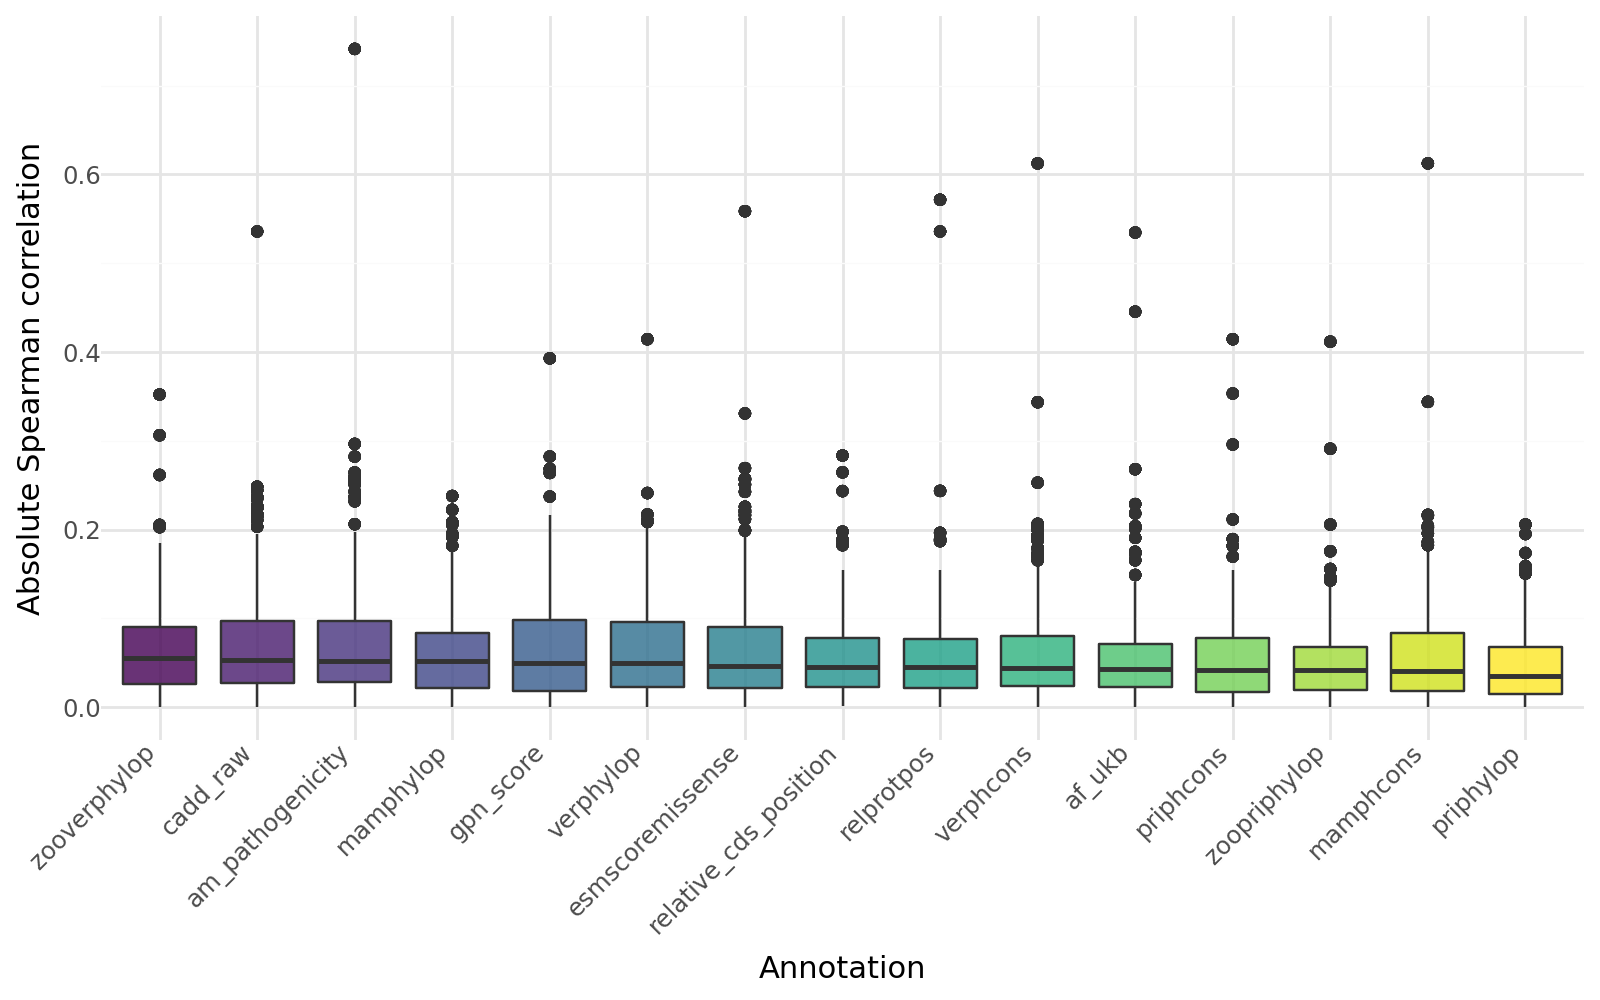

In [29]:
# Invert the mapping: annotation -> category
annotation_to_cat = {
    ann: cat
    for cat, anns in config['rare_variant_annotations'].items()
    for ann in anns
}

# Add mapped category column (unmatched will be null)
# corr_df_plot = corr_df.with_columns(
corr_df_plot = filtered.with_columns(
    pl.col("annotation")
      .replace(annotation_to_cat, default=None)  # unmatched → None
      .alias("category")
)

corr_df_plot = corr_df_plot.with_columns(
    pl.col('annotation').str.split('_').list.get(-1).alias('aggregation')
)

med_df = corr_df_plot.drop_nans().group_by("annotation").agg([
    pl.col("abs_corr").median().alias("median_abs_corr")
])

corr_pd = med_df.join(corr_df_plot, on='annotation').to_pandas()

corr_pd['annotation'] = pd.Categorical(
    corr_pd['annotation'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['annotation'].unique(),
    ordered=True
)

# Plot
(
    ggplot(corr_pd, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    # facet_wrap('category', scales='free') +
    # scale_y_sqrt() +
    # coord_flip() +
    labs(
        x='Annotation',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [38]:
filtered['annotation'].value_counts(sort=True)

annotation,count
str,u32
"""gpn_score""",3345
"""esmscoremissense""",3345
"""verphylop""",3345
"""relative_cds_position""",3345
"""relprotpos""",3345
…,…
"""cadd_raw""",3345
"""mamphcons""",3345
"""verphcons""",3345


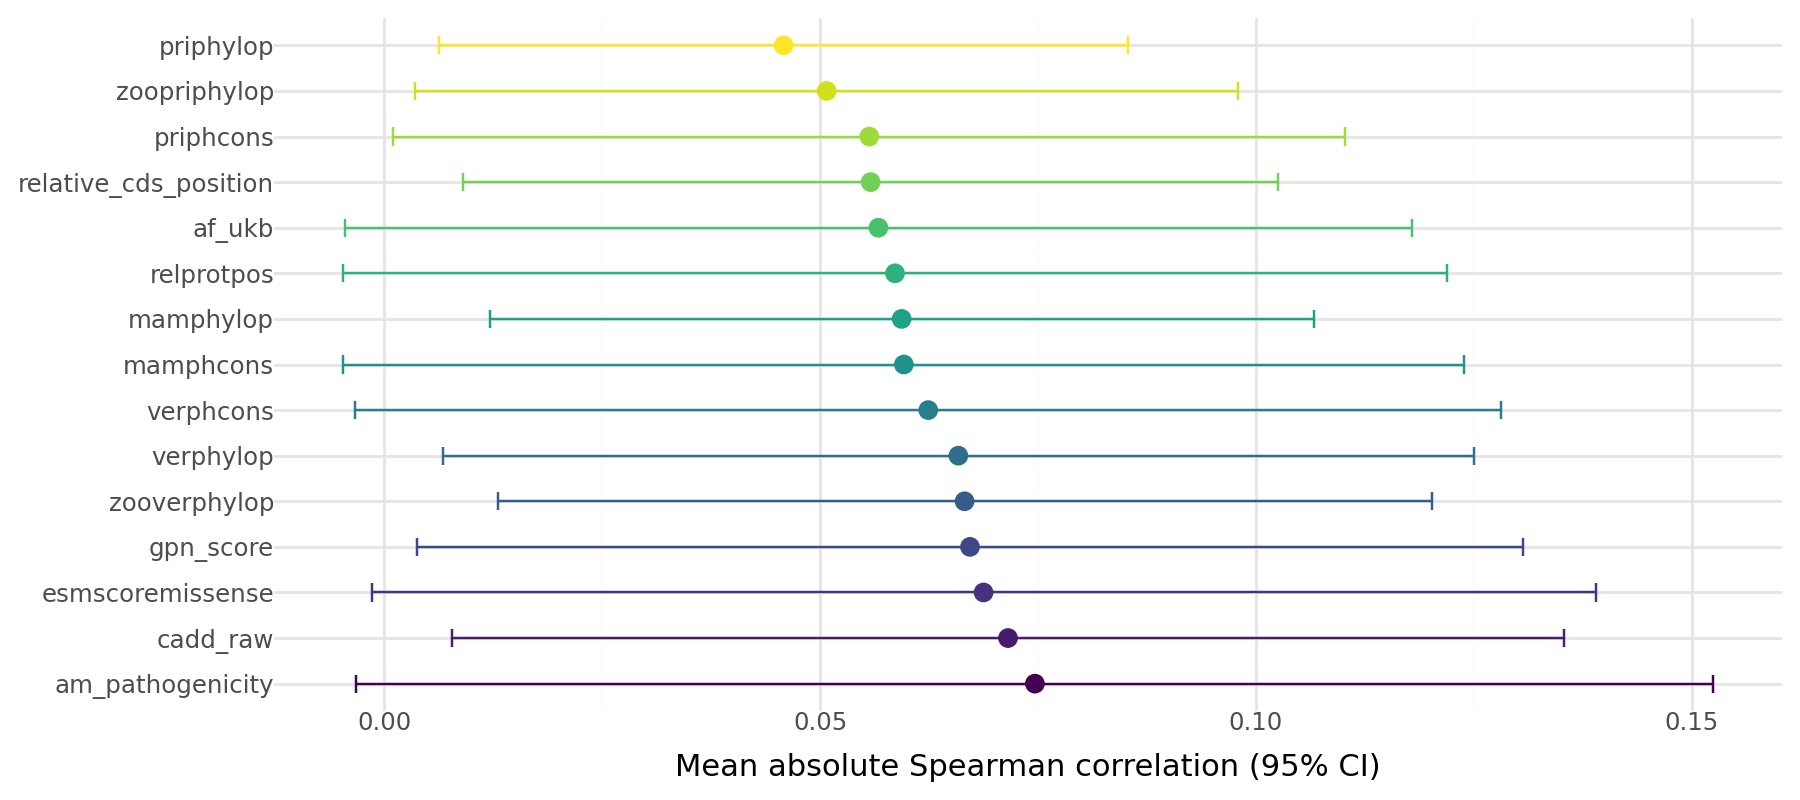

In [37]:
confidence_level = 0.95
alpha = 1 - confidence_level
lower_percentile = (alpha / 2) * 100
upper_percentile = (1 - alpha / 2) * 100

plt_df = (
    filtered.group_by(['annotation'])
    .agg(
        pl.col('abs_corr').mean().alias('mean_abs_corr'),
        pl.col('abs_corr').std().alias('se_abs_corr'),
        pl.col('abs_corr').quantile(lower_percentile / 100).alias('abs_corr_ci_lower'),
        pl.col('abs_corr').quantile(upper_percentile / 100).alias('abs_corr_ci_upper')
    )
    .with_columns(
        (pl.col('mean_abs_corr') - pl.col('se_abs_corr')).alias('abs_corr_mean_lower'),
        (pl.col('mean_abs_corr') + pl.col('se_abs_corr')).alias('abs_corr_mean_upper'),
    )
    .sort('mean_abs_corr', descending=True)
)

summary_df = plt_df.to_pandas()

# Ordering by mean correlation
summary_df['annotation'] = pd.Categorical(
    summary_df['annotation'],
    categories=summary_df.sort_values('mean_abs_corr', ascending=False)['annotation'],
    ordered=True
)

summary_df['color_dms'] = summary_df['annotation'].str.startswith('HXK4').map({True: 'DMS', False: 'Other'})

# Plot
(
    ggplot(summary_df, aes(x='annotation', y='mean_abs_corr', color='annotation')) +
    geom_point(size=3) +
    geom_errorbar(aes(ymin='abs_corr_mean_lower', ymax='abs_corr_mean_upper'), width=0.4) +
    coord_flip() +
    theme_minimal() +
    labs(
        x='',
        y='Mean absolute Spearman correlation (95% CI)'
    ) +
    theme(
        figure_size=(9, 4),
        legend_position='none'
    )
)

## Ideas

- facet by phenotype
- when is am > conservation
- 